In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from scipy.integrate import solve_ivp

import tinyDA as tda

In [18]:
# extract parameter states from a chain (or sampler output)
def extract_parameters(list):
    output = []
    for element in list:
        output.append(element.parameters.tolist()[0])

    return(np.array(output))

In [2]:
my_prior = stats.uniform(loc=-50, scale=100)

In [3]:
sigma = 1
# define the likelihood
s0, m0 = 4, 4
s1, m1 = 2, 2
s2, m2 = 1, 0

cov_likelihood_l0 = (s0*sigma)**2*np.eye(1)
cov_likelihood_l1 = (s1*sigma)**2*np.eye(1)
cov_likelihood_l2 = (s2*sigma)**2*np.eye(1)

my_loglike_l2 = tda.GaussianLogLike(np.eye(1)*m2, cov_likelihood_l2)
my_loglike_l1 = tda.AdaptiveGaussianLogLike(np.eye(1)*m1, cov_likelihood_l1)
my_loglike_l0 = tda.AdaptiveGaussianLogLike(np.eye(1)*m0, cov_likelihood_l0)

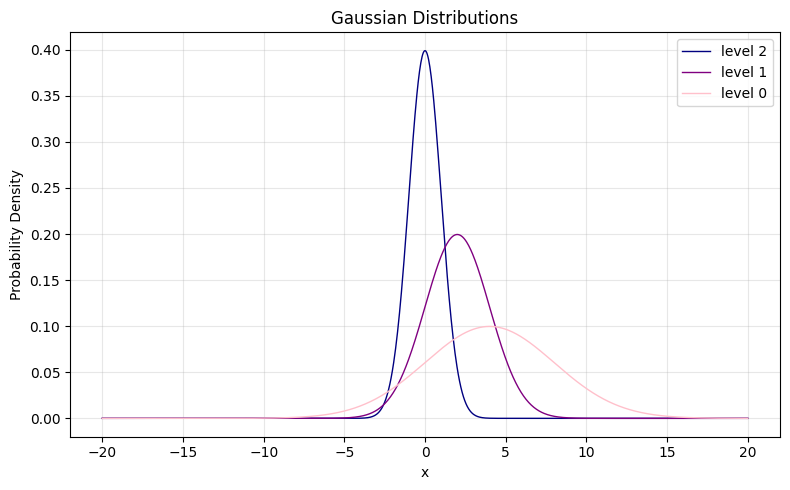

In [7]:
means = [m2, m1, m0]    # Means of the distributions
stds = [s2, s1, s0]  # Standard deviations
colors = ['navy', 'purple', 'pink']  # Colors for each plot
labels = ['level 2', 'level 1', 'level 0']

# Create x values
x = np.linspace(-20, 20, 1000)

# Plot each Gaussian
plt.figure(figsize=(8, 5))
for mean, std, color, label in zip(means, stds, colors, labels):
    y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
    plt.plot(x, y, color=color, linewidth=1, label=label)

# Add labels and legend
plt.title('Gaussian Distributions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

In [9]:
# define a model.
def my_model(parameter):
    h = 1
    alpha=-1000
    return parameter + h**alpha

In [10]:
# set up the link factories
my_posterior_l2 = tda.Posterior(my_prior, my_loglike_l2, my_model)
my_posterior_l1 = tda.Posterior(my_prior, my_loglike_l1, my_model)
my_posterior_l0 = tda.Posterior(my_prior, my_loglike_l0, my_model)

my_posteriors = [my_posterior_l0, my_posterior_l1, my_posterior_l2]

In [11]:
# get the maximum a posteriori point.
MAP = tda.get_MAP(my_posterior_l2)

In [12]:
MAP

array([-0.99999662])

In [13]:
# random walk Metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = 0.1
rwmh_adaptive = True
my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

# Adaptive Metropolis
#am_cov = np.eye(true_parameters.size)
#am_t0 = 100
#am_sd = None
#am_epsilon = 1e-6
#am_adaptive = True
#my_proposal = tda.AdaptiveMetropolis(C0=am_cov, t0=am_t0, sd=am_sd, epsilon=am_epsilon)

#dream_m0 = 1000
#dream_delta = 1
#dream_Z_method = 'lhs'
#dream_adaptive = True
#my_proposal = tda.DREAMZ(M0=dream_m0, delta=dream_delta, Z_method=dream_Z_method, adaptive=dream_adaptive)

In [14]:
import os
if "CI" in os.environ:
    iterations = 120
    burnin = 20
else:
    iterations = 2500
    burnin = 500

In [15]:
# initialise the chain
my_chain = tda.sample(my_posteriors, my_proposal, iterations=100, n_chains=1, initial_parameters=MAP, subchain_length=10, randomize_subchain_length=True)#, adaptive_error_model='state-independent')

Sampling chain 1/1


Running chain, α = 0.49: 100%|██████████| 100/100 [00:01<00:00, 63.63it/s]


In [16]:
burnin=10

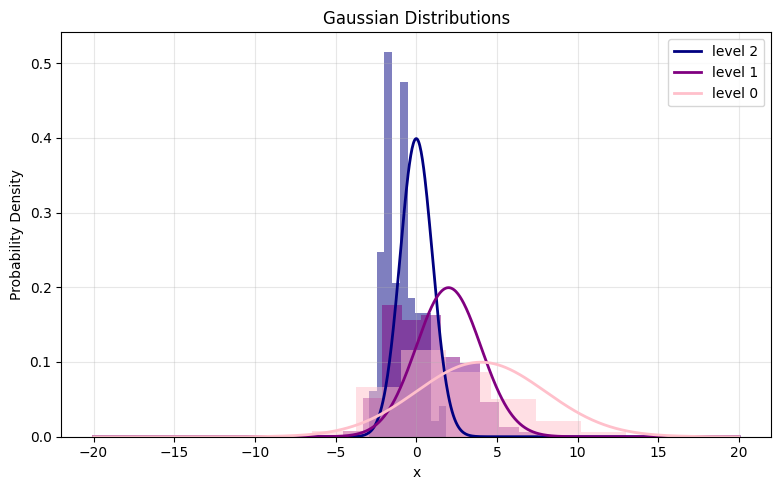

In [20]:
means = [m2, m1, m0]    # Means of the distributions
stds = [s2, s1, s0]  # Standard deviations
colors = ['navy', 'purple', 'pink']  # Colors for each plot
labels = ['level 2', 'level 1', 'level 0']

# Create x values
x = np.linspace(-20, 20, 1000)

# Plot each Gaussian
plt.figure(figsize=(8, 5))
for mean, std, color, label in zip(means, stds, colors, labels):
    y = (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean)/std)**2)
    plt.plot(x, y, color=color, linewidth=2, label=label)

# Add labels and legend
plt.title('Gaussian Distributions')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
#plt.show()

plt.hist(extract_parameters(my_chain['chain_l2_0']), density=True, alpha=0.5, color=colors[0])
plt.hist(extract_parameters(my_chain['chain_l1_0']), density=True, alpha=0.5, color=colors[1])
plt.hist(extract_parameters(my_chain['chain_l0_0']), density=True, alpha=0.5, color=colors[2])

plt.show()